# Model Training

Building and compare different classification models

In [2]:
# some imports 
import pickle

In [3]:
# loading data

with open("/Users/andrejartuschenko/Desktop/mailharpoon/backend/data/processed/preprocessed_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train_full = data["X_train_full"]
X_test_full = data["X_test_full"]
X_train_url = data["X_train_url"]
X_test_url = data["X_test_url"]
y_train = data["y_train"]
y_test = data["y_test"]

In [4]:
print(X_train_full.shape, X_train_url.shape)
print(y_train.value_counts(normalize=True))

(8844, 30) (8844, 8)
result_bin
0    0.556988
1    0.443012
Name: proportion, dtype: float64


### Model Building Logistic Regression

In [5]:
# some imports for logisitic regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


## Model Logistic Regression with all Features

In [6]:
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

In [7]:
log_model.fit(X_train_full, y_train)
pred = log_model.predict(X_test_full)

In [8]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))


Confusion Matrix:
[[1169   62]
 [  97  883]]


In [9]:
print("\nClassification Report:")
print(classification_report(y_test, pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      1231
           1       0.93      0.90      0.92       980

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [10]:
# ROC-AUC
probs = log_model.predict_proba(X_test_full)[:, 1]
print("\nROC-AUC:", roc_auc_score(y_test, probs))


ROC-AUC: 0.9785034566222915


### Model Performance Overview Logistic regression with all features

**Accuracy:** 0.93  
**ROC-AUC:** 0.979  

**Precision:** 0.93  
**Recall:** 0.90  
**F1-score:** 0.92 

Meaning: 
- 90% of phishing webistes were correctly identified
- 10% of phishing websites werde missed (false negatives).
- when the model predict phishing, it is correct 93% of the time.

- The high ROC-AUC (0.979) indicates excellent class separability.
- The dataset appears to be largely linearly separable.
- Even a linear model performs very strongly, suggesting that the engineered features contain strong predictive signals.
- This establishes a strong baseline before testing more complex models.


## Model Logisitic Regression with URL-only

In [11]:
log_model.fit(X_train_url, y_train)
pred_url = log_model.predict(X_test_url)

In [12]:
print("\nConfusion Matrix (URL-only):")
print(confusion_matrix(y_test, pred_url))


Confusion Matrix (URL-only):
[[935 296]
 [345 635]]


In [13]:
print("\nClassification Report (URL-only):")
print(classification_report(y_test, pred_url))


Classification Report (URL-only):
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      1231
           1       0.68      0.65      0.66       980

    accuracy                           0.71      2211
   macro avg       0.71      0.70      0.70      2211
weighted avg       0.71      0.71      0.71      2211



In [14]:
probs_url = log_model.predict_proba(X_test_url)[:, 1]
print("\nROC-AUC (URL-only):", roc_auc_score(y_test, probs_url))


ROC-AUC (URL-only): 0.7829639085528606


## Comparison: Full Feature Set vs URL-Only Features

URL-only features, performance dropped significantly:

Accuracy: 0.71
F1-score (Phishing): 0.66
Recall (Phishing): 0.65
ROC-AUC: 0.78

**Interpretation**

The substantial decline in performance indicates that URL structure alone is not sufficient to reliably detect phishing websites in this dataset.
In particular, the recall for phishing (0.65) suggests that a large number of phishing URLs are incorrectly classified as legitimate. This would be problematic in a real-world deployment, where missing phishing attacks poses a serious security risk.

The removed features (e.g., SSL state, domain registration length, traffic-based indicators) appear to contribute significantly to the model’s discriminative power.

**Conclusion**

While a URL-only approach simplifies deployment and avoids external lookups, it comes at the cost of substantially reduced predictive performance. A hybrid or enriched feature approach is likely necessary for robust phishing detection.

# Random Forrest - Full Feature Set

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [16]:
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X_train_full, y_train)

pred_rf_full = rf_full.predict(X_test_full)
probs_rf_full = rf_full.predict_proba(X_test_full)[:, 1]

In [17]:
print("\nConfusion Matrix (RF Full):")
print(confusion_matrix(y_test, pred_rf_full))

print("\nClassification Report (RF Full):")
print(classification_report(y_test, pred_rf_full))

print("\nROC-AUC (RF Full):", roc_auc_score(y_test, probs_rf_full))


Confusion Matrix (RF Full):
[[1212   19]
 [  33  947]]

Classification Report (RF Full):
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1231
           1       0.98      0.97      0.97       980

    accuracy                           0.98      2211
   macro avg       0.98      0.98      0.98      2211
weighted avg       0.98      0.98      0.98      2211


ROC-AUC (RF Full): 0.9966515525787895


# Random Forest URL-Only

In [18]:
rf_url = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_url.fit(X_train_url, y_train)

pred_rf_url = rf_url.predict(X_test_url)
probs_rf_url = rf_url.predict_proba(X_test_url)[:, 1]

In [19]:
print("\nConfusion Matrix (RF URL-only):")
print(confusion_matrix(y_test, pred_rf_url))

print("\nClassification Report (RF URL-only):")
print(classification_report(y_test, pred_rf_url))

print("\nROC-AUC (RF URL-only):", roc_auc_score(y_test, probs_rf_url))


Confusion Matrix (RF URL-only):
[[860 371]
 [218 762]]

Classification Report (RF URL-only):
              precision    recall  f1-score   support

           0       0.80      0.70      0.74      1231
           1       0.67      0.78      0.72       980

    accuracy                           0.73      2211
   macro avg       0.74      0.74      0.73      2211
weighted avg       0.74      0.73      0.73      2211


ROC-AUC (RF URL-only): 0.8275493625557453


## Feature importance Plot

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importances extrahieren
importances = rf_full.feature_importances_

# In DataFrame packen
feat_importance = pd.DataFrame({
    "feature": X_train_full.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_importance.head(15)

,feature,importance
7,sslfinal_state,0.321124
13,url_of_anchor,0.256848
25,web_traffic,0.071184
6,having_sub_domain,0.061351
14,links_in_tags,0.042376
5,prefix_suffix,0.040908
15,sfh,0.020119
12,request_url,0.018942
28,links_pointing_to_page,0.018769
8,domain_registeration_length,0.016994


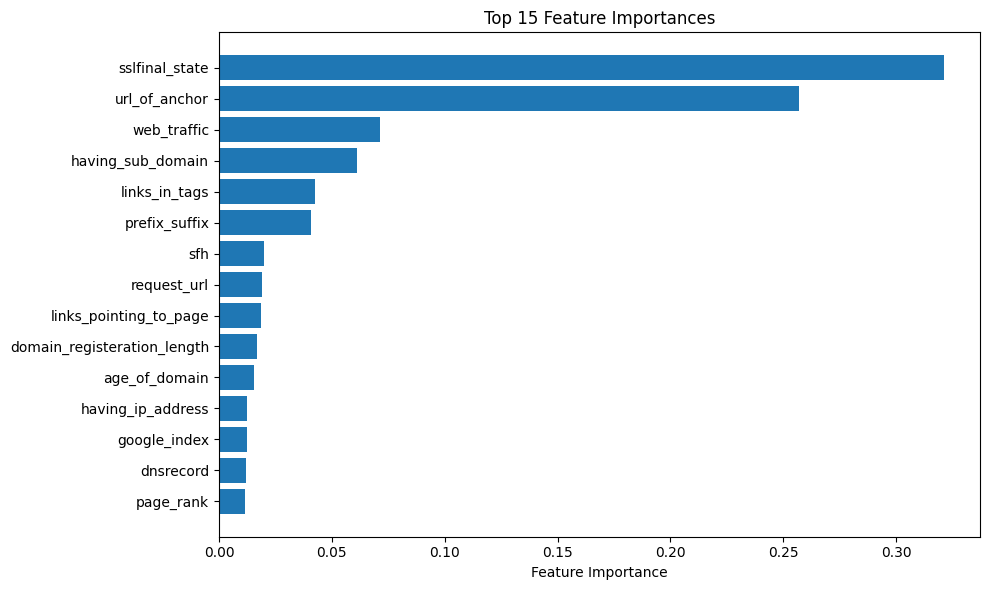

In [21]:
# top 15 features 

plt.figure(figsize=(10,6))
plt.barh(
    feat_importance["feature"].head(15)[::-1],
    feat_importance["importance"].head(15)[::-1]
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()

In [22]:
feat_importance["importance"].describe()

count    30.000000
mean      0.033333
std       0.072074
min       0.001433
25%       0.004730
50%       0.010116
75%       0.018899
max       0.321124
Name: importance, dtype: float64

### Feature Insights 

**sslfinal_state** carries 32% of the toal decision information. This also explains why the models perform significantly worse with the URL-only dataset.
We have two features that dominate the model. This is a very unevenly distributed feature importance.
Our models basically learn: if SSL is "bad", then phishing.



# Model definition and comparison on full data set

In [23]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

In [24]:
# models as dict

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(max_iter=2000, random_state=42))
    ]),
}


In [25]:
# cross validation setup

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

In [26]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    scores = cross_validate(
        model,
        X_train_full,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    results.append({
        "Model": name,
        "Accuracy": np.mean(scores["test_accuracy"]),
        "F1 (Phishing)": np.mean(scores["test_f1"]),
        "Recall (Phishing)": np.mean(scores["test_recall"]),
        "ROC-AUC": np.mean(scores["test_roc_auc"])
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
results_df

Training Logistic Regression...
Training KNN...
Training SVM...
Training Naive Bayes...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training MLP...


,Model,Accuracy,F1 (Phishing),Recall (Phishing),ROC-AUC
7,MLP,0.963931,0.958995,0.952014,0.994863
5,Random Forest,0.969471,0.965384,0.960947,0.994527
6,Gradient Boosting,0.948666,0.941540,0.933128,0.989911
2,SVM,0.947196,0.939384,0.923686,0.986960
1,KNN,0.937585,0.929158,0.923939,0.980363
0,Logistic Regression,0.928200,0.917969,0.906841,0.978716
3,Naive Bayes,0.600860,0.689124,0.998469,0.967420
4,Decision Tree,0.956242,0.950268,0.943337,0.967192


## Model Comparison and Evaluation for the full Feature Set

Trained and evaluatest multiple ML models: **Logistic Regression, KNN, SVM, Naive Bayes, Decision Tree, Random Forest, Gradient Boosting, and MLP**

### Overall Performance

Most models achieved strong performance, with Accuracy values above 0.93 and ROC-AUC values above 0.97. However, for a phishing detection use case, **F1-score (Phishing class)** and **Recall (Phishing class)** are the most critical metrics, since false negatives (undetected phishing websites) pose a higher security risk than false positives.

### Key findings

- **Random Forrest** achieved the highest F1-score for the phishing class and very strong recall, combined with excellent ROC-AUC
- **Multi-Layer Perceptron (MLP)** achieved the highest ROC-AUC overall and performed only slightly below Random Forrest in F1 and Recall
- **Gradient Boosting** and **SVM** also performed well but did not surpass Random Forest or MLP
- **Naive Bayes** showed extremely high recall but very low overall accuracy, indicating that it over-predicts the phishing class and produces too many false positives

### Conclusion 

Based on F1-score, recall for phishing detection, and overall discriminative power (ROC-AUC), Random Forrest and MLP sllightly outperform the other models. Random Forest is more stable and interpretable, while MLP provides very strong predective performance with higher modeling flexibility.

I select therefore both models as the top candidates for final evaluation an potential deployment.




## train vs. test performance

In [27]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

def evaluate_models(models, X_train, y_train, X_test, y_test):
    
    results = []
    
    for name, model in models.items():
        
        # Train
        model.fit(X_train, y_train)
        
        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        # Probabilities (für ROC-AUC)
        if hasattr(model, "predict_proba"):
            train_proba = model.predict_proba(X_train)[:, 1]
            test_proba = model.predict_proba(X_test)[:, 1]
        else:
            train_proba = None
            test_proba = None
        
        results.append({
            "Model": name,
            "Train Accuracy": accuracy_score(y_train, train_pred),
            "Test Accuracy": accuracy_score(y_test, test_pred),
            "Train F1 (Phishing)": f1_score(y_train, train_pred),
            "Test F1 (Phishing)": f1_score(y_test, test_pred),
            "Train Recall (Phishing)": recall_score(y_train, train_pred),
            "Test Recall (Phishing)": recall_score(y_test, test_pred),
            "Train ROC-AUC": roc_auc_score(y_train, train_proba) if train_proba is not None else None,
            "Test ROC-AUC": roc_auc_score(y_test, test_proba) if test_proba is not None else None
        })
    
    return pd.DataFrame(results).sort_values("Test F1 (Phishing)", ascending=False)

In [28]:
results_df = evaluate_models(models, X_train_full, y_train, X_test_full, y_test)
results_df

,Model,Train Accuracy,Test Accuracy,Train F1 (Phishing),Test F1 (Phishing),Train Recall (Phishing),Test Recall (Phishing),Train ROC-AUC,Test ROC-AUC
5,Random Forest,0.989371,0.976481,0.988001,0.973279,0.987749,0.966327,0.999682,0.996652
7,MLP,0.988354,0.972863,0.986854,0.969294,0.986728,0.966327,0.999632,0.996385
4,Decision Tree,0.989371,0.969697,0.987964,0.965446,0.984686,0.955102,0.999715,0.976431
2,SVM,0.955676,0.956128,0.949223,0.949819,0.935171,0.936735,0.990885,0.989048
6,Gradient Boosting,0.951832,0.950249,0.945146,0.943532,0.936702,0.937755,0.991167,0.991288
1,KNN,0.962913,0.946630,0.957906,0.939112,0.952527,0.928571,0.995446,0.985581
0,Logistic Regression,0.929444,0.928087,0.919276,0.917403,0.906840,0.901020,0.979569,0.978503
3,Naive Bayes,0.600972,0.616011,0.689157,0.697542,0.998469,0.998980,0.967939,0.967709


From the initial comparison, I found out that the top three models are: 

**Random Forest**, **MLP**, **Decision Tree**

I will proceed with Random Forest.

## Random Forest Cross Validation

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

#we neet the full data set for the cross validation
X_full = pd.concat([X_train_full, X_test_full])
y_full = pd.concat([y_train, y_test])

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    rf_final,
    X_full, y_full,  
    cv=cv,
    scoring=["accuracy", "f1", "recall", "roc_auc"],
    n_jobs=-1
)

pd.DataFrame(scores).drop(columns=["fit_time","score_time"]).agg(["mean","std"])

,test_accuracy,test_f1,test_recall,test_roc_auc
mean,0.964993,0.960103,0.950798,0.995724
std,0.002183,0.002559,0.006084,0.000598


To assess the stability and generalization capability of the Random Forest classifier, a 5-fold Stratified Cross-Validation was performed on the full dataset. Stratification ensures that the class distribution (phishing vs. legitimate) is preserved across all folds.

### Interpretation:

The model demonstrates:

High predictive performance across all evaluation metrics.

Very low standard deviation, indicating strong stability across different data splits.

Consistent recall for phishing detection, which is critical in a security context.

Excellent discriminative power, as reflected by the near-perfect ROC-AUC.

The small variance between folds suggests that the Random Forest model generalizes well and is not overly dependent on a specific train-test split. This confirms that the previously observed strong test performance is not due to randomness or data leakage.

## Final Modell Training

In [30]:
rf_final = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_full, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Final Test-Evaluation

In [31]:
pred_test = rf_final.predict(X_test_full)
probs_test = rf_final.predict_proba(X_test_full)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_test))

print("\nClassification Report:")
print(classification_report(y_test, pred_test))

print("\nROC-AUC:", roc_auc_score(y_test, probs_test))

Confusion Matrix:
[[1206   25]
 [  38  942]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1231
           1       0.97      0.96      0.97       980

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


ROC-AUC: 0.9962756345430129


In [32]:
# threshold comparison
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.linspace(0.1, 0.9, 17)

results = []

for t in thresholds:
    pred_t = (probs_test >= t).astype(int)
    results.append({
        "threshold": t,
        "F1": f1_score(y_test, pred_t),
        "Recall": recall_score(y_test, pred_t),
        "Precision": precision_score(y_test, pred_t)
    })

import pandas as pd
pd.DataFrame(results).sort_values("F1", ascending=False).head()

,threshold,F1,Recall,Precision
8,0.50,0.967643,0.961224,0.974147
10,0.60,0.966093,0.944898,0.988260
9,0.55,0.965303,0.951020,0.980021
7,0.45,0.964885,0.967347,0.962437
6,0.40,0.960161,0.971429,0.949153


## Final Threshold Selection

After evaluating multiple probability thresholds, a threshold of **0.5** was selected.

This threshold achieved the highest F1-score while maintaining a strong balance between recall (phishing detection rate) and precision (false alarm control).

Since 0.5 also represents the standard probabilistic decision boundary, it ensures interpretability, stability, and reproducibility for deployment.

The final Random Forest model will therefore use a classification threshold of 0.5.

### Save rf full Model + features

In [33]:
import os, json, joblib

os.makedirs("/Users/andrejartuschenko/Desktop/mailharpoon/backend/models", exist_ok=True)

# saving model 
joblib.dump(rf_final, "/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_full_final.joblib")

['/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_full_final.joblib']

In [34]:
# saving features (full data set)

with open("/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_full_features.json", "w") as f:
    json.dump(list(X_train_full.columns), f)

In [35]:
# saving threshold

with open("/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_threshold.json", "w") as f:
    json.dump({"threshold": 0.5}, f)

## URL-only RF

In [36]:
rf_url = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_url.fit(X_train_url, y_train)

pred_url = rf_url.predict(X_test_url)
probs_url = rf_url.predict_proba(X_test_url)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_url))

print("\nClassification Report:")
print(classification_report(y_test, pred_url))

print("\nROC-AUC:", roc_auc_score(y_test, probs_url))

Confusion Matrix:
[[858 373]
 [217 763]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.70      0.74      1231
           1       0.67      0.78      0.72       980

    accuracy                           0.73      2211
   macro avg       0.73      0.74      0.73      2211
weighted avg       0.74      0.73      0.73      2211


ROC-AUC: 0.8276687279298396


In [37]:
# cross validation rf url-only

X_full_url = pd.concat([X_train_url, X_test_url])
y_full = pd.concat([y_train, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    rf_url,
    X_full_url,
    y_full,
    cv=cv,
    scoring=["accuracy", "f1", "recall", "roc_auc"],
    n_jobs=-1
)

pd.DataFrame(scores).drop(columns=["fit_time","score_time"]).agg(["mean","std"])

/Users/andrejartuschenko/Desktop/mailharpoon/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/andrejartuschenko/Desktop/mailharpoon/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/andrejartuschenko/Desktop/mailharpoon/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

,test_accuracy,test_f1,test_recall,test_roc_auc
mean,0.738037,0.726783,0.786239,0.819589
std,0.011395,0.010014,0.011517,0.011965


In [38]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=25,              
    scoring="f1",           
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train_url, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [39]:
print("Best Parameters:")
print(search.best_params_)

print("\nBest CV F1:")
print(search.best_score_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

Best CV F1:
0.7245017229153329


In [40]:
best_rf_url = search.best_estimator_

pred = best_rf_url.predict(X_test_url)
probs = best_rf_url.predict_proba(X_test_url)[:, 1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.80      0.70      0.74      1231
           1       0.67      0.78      0.72       980

    accuracy                           0.73      2211
   macro avg       0.73      0.74      0.73      2211
weighted avg       0.74      0.73      0.73      2211

ROC-AUC: 0.8270727299855767


In [41]:
# Feature Importance extraction
importances = best_rf_url.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train_url.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp

,feature,importance
6,having_sub_domain,0.443068
5,prefix_suffix,0.341116
1,url_length,0.051593
0,having_ip_address,0.050783
2,shortining_service,0.037858
3,having_at_symbol,0.027154
4,double_slash_redirecting,0.026563
7,https_token,0.021865


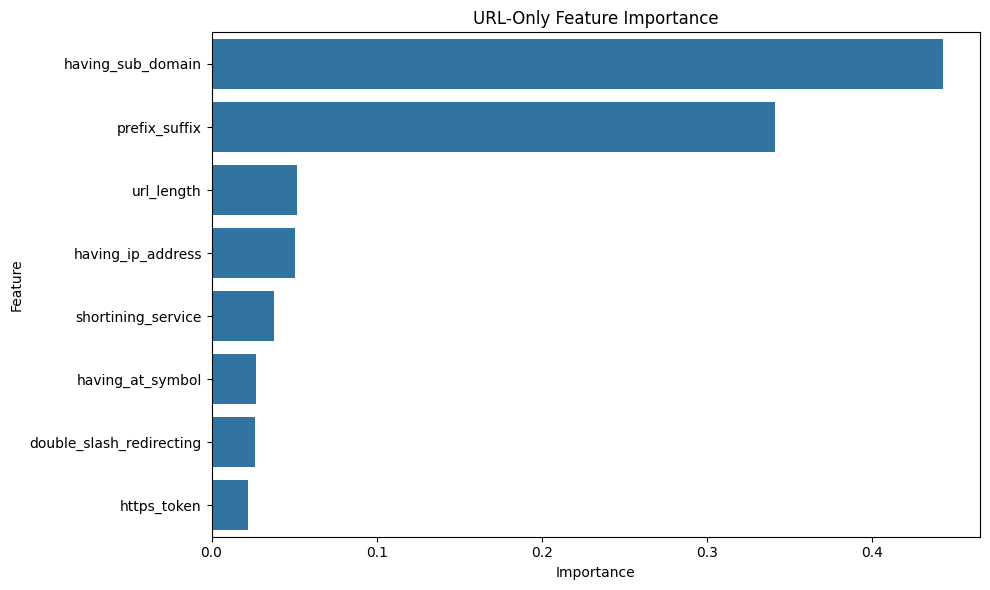

In [42]:
import seaborn as sns


plt.figure(figsize=(10,6))
sns.barplot(
    data=feat_imp,
    x="importance",
    y="feature"
)

plt.title("URL-Only Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [43]:
# rf url only final training model

rf_url_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    random_state=42,
    n_jobs=-1
)

rf_url_final.fit(X_train_url, y_train)

probs = rf_url_final.predict_proba(X_test_url)[:, 1]
pred  = (probs >= 0.5).astype(int)

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, probs))

              precision    recall  f1-score   support

           0       0.80      0.70      0.74      1231
           1       0.67      0.78      0.72       980

    accuracy                           0.73      2211
   macro avg       0.73      0.74      0.73      2211
weighted avg       0.74      0.73      0.73      2211

ROC-AUC: 0.8270727299855767


## Saving rf url only model

In [44]:
os.makedirs("/Users/andrejartuschenko/Desktop/mailharpoon/backend/models", exist_ok=True)

# saving model 
joblib.dump(rf_url_final, "/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_url_final.joblib")

['/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_url_final.joblib']

In [45]:
with open("/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_url_only/rf_url_features.json", "w") as f:
    json.dump(list(X_train_url.columns), f)

In [46]:
# saving threshold

with open("/Users/andrejartuschenko/Desktop/mailharpoon/backend/models/rf_url_only/rf_url_only_threshold.json", "w") as f:
    json.dump({"threshold": 0.5}, f)